In [3]:
!pip install -q tensorflow==2.20.0
!pip install -q tensorflow-model-optimization
!pip install -q librosa soundfile
!pip install -q scikit-learn matplotlib tqdm

In [4]:
import tensorflow as tf
import librosa
import numpy as np

print("TensorFlow:", tf.__version__)
print("Librosa:", librosa.__version__)
print("NumPy:", np.__version__)

TensorFlow: 2.20.0
Librosa: 0.11.0
NumPy: 2.0.2


In [5]:
import os

folders = [
    "dataset",
    "models",
    "results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [6]:
!git clone https://github.com/karolpiczak/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 22.28 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [7]:
import os

audio_path = "ESC-50/audio"

audio_files = [
    f for f in os.listdir(audio_path)
    if f.endswith(".wav")
]

print("Total Audio Files:", len(audio_files))
print("First 5 Files:")
print(audio_files[:5])

Total Audio Files: 2000
First 5 Files:
['4-188003-A-34.wav', '5-242932-A-26.wav', '4-99644-B-4.wav', '2-109316-A-32.wav', '1-47714-A-16.wav']


In [8]:
import pandas as pd

meta = pd.read_csv(
    "ESC-50/meta/esc50.csv"
)

print(meta.head())

            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


In [9]:
categories = sorted(
    meta["category"].unique()
)

print("Number of classes:", len(categories))

print("\nClasses:")
print(categories)

Number of classes: 50

Classes:
['airplane', 'breathing', 'brushing_teeth', 'can_opening', 'car_horn', 'cat', 'chainsaw', 'chirping_birds', 'church_bells', 'clapping', 'clock_alarm', 'clock_tick', 'coughing', 'cow', 'crackling_fire', 'crickets', 'crow', 'crying_baby', 'dog', 'door_wood_creaks', 'door_wood_knock', 'drinking_sipping', 'engine', 'fireworks', 'footsteps', 'frog', 'glass_breaking', 'hand_saw', 'helicopter', 'hen', 'insects', 'keyboard_typing', 'laughing', 'mouse_click', 'pig', 'pouring_water', 'rain', 'rooster', 'sea_waves', 'sheep', 'siren', 'sneezing', 'snoring', 'thunderstorm', 'toilet_flush', 'train', 'vacuum_cleaner', 'washing_machine', 'water_drops', 'wind']


In [10]:
from IPython.display import Audio

sample = "ESC-50/audio/" + meta.iloc[0]["filename"]

print("Category:", meta.iloc[0]["category"])

Audio(sample)

Category: dog


In [11]:
esc10 = meta[
    meta["esc10"] == True
]

print("ESC-10 Samples:", len(esc10))

print("\nClasses:")
print(sorted(esc10["category"].unique()))

ESC-10 Samples: 400

Classes:
['chainsaw', 'clock_tick', 'crackling_fire', 'crying_baby', 'dog', 'helicopter', 'rain', 'rooster', 'sea_waves', 'sneezing']


In [12]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

In [13]:
sample_row = esc10.iloc[0]

audio_file = "ESC-50/audio/" + sample_row["filename"]

audio, sr = librosa.load(
    audio_file,
    sr=16000
)

print("Category:", sample_row["category"])
print("Sample Rate:", sr)
print("Audio Shape:", audio.shape)

Category: dog
Sample Rate: 16000
Audio Shape: (80000,)


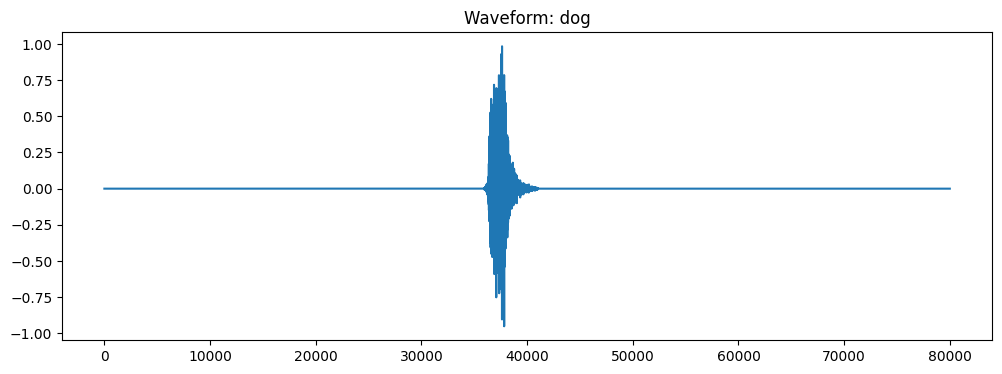

In [14]:
plt.figure(figsize=(12,4))

plt.plot(audio)

plt.title(
    f"Waveform: {sample_row['category']}"
)

plt.show()

In [15]:
mfcc = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13,
    n_fft=512,
    hop_length=160
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (13, 501)


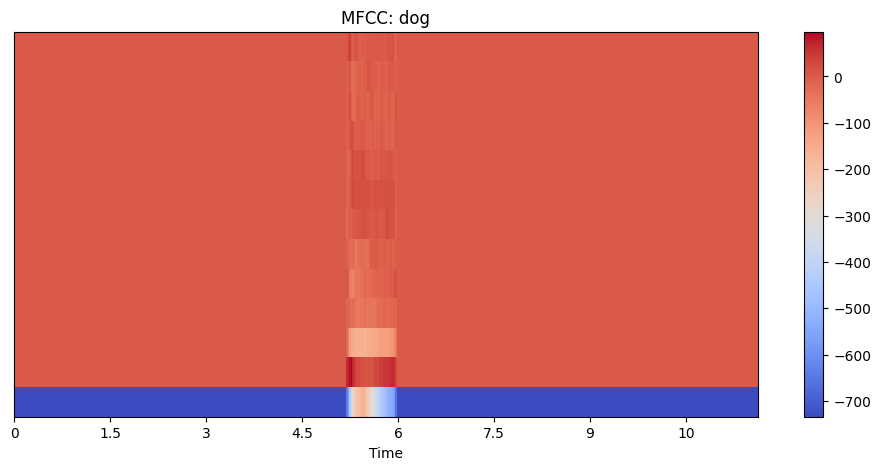

In [16]:
plt.figure(figsize=(12,5))

librosa.display.specshow(
    mfcc,
    x_axis='time'
)

plt.colorbar()

plt.title(
    f"MFCC: {sample_row['category']}"
)

plt.show()

In [28]:
MAX_FRAMES = 500

def extract_feature(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=16000
    )

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=40,
        n_fft=512,
        hop_length=160
    )

    mel_db = librosa.power_to_db(
        mel,
        ref=np.max
    )

    if mel_db.shape[1] < MAX_FRAMES:

        pad_width = MAX_FRAMES - mel_db.shape[1]

        mel_db = np.pad(
            mel_db,
            ((0,0),(0,pad_width))
        )

    else:

        mel_db = mel_db[:, :MAX_FRAMES]

    return mel_db

In [29]:
test_feature = extract_feature(
    audio_file
)

print(
    "Final Feature Shape:",
    test_feature.shape
)

Final Feature Shape: (40, 500)


In [30]:
X = []
y = []

categories = sorted(
    esc10["category"].unique()
)

label_map = {
    cat:i
    for i,cat in enumerate(categories)
}

for _, row in esc10.iterrows():

    path = (
        "ESC-50/audio/" +
        row["filename"]
    )

    try:

        feature = extract_feature(path)

        X.append(feature)

        y.append(
            label_map[
                row["category"]
            ]
        )

    except Exception as e:

        print(
            "Error:",
            row["filename"]
        )

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (400, 40, 500)
y shape: (400,)


In [31]:
X = X[..., np.newaxis]

print(
    "CNN Input Shape:",
    X.shape
)

CNN Input Shape: (400, 40, 500, 1)


In [ ]:
// train test split

In [32]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (320, 40, 500, 1)
Test: (80, 40, 500, 1)


In [33]:
mean = np.mean(X_train)
std = np.std(X_train)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

print("Normalized!")

Normalized!


In [34]:
import tensorflow as tf

model = tf.keras.Sequential([

    tf.keras.Input(shape=X_train.shape[1:]),

    tf.keras.layers.Conv2D(
        16,
        (3,3),
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        padding='same',
        activation='relu'
    ),

    tf.keras.layers.BatchNormalization(),

    tf.keras.layers.MaxPooling2D((2,2)),

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        64,
        activation='relu'
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        len(categories),
        activation='softmax'
    )
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 40, 500, 16)    │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 500, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 20, 250, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 20, 250, 32)    │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 250, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 125, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,754 (30.29 KB)

 Trainable params: 7,658 (29.91 KB)

 Non-trainable params: 96 (384.00 B)

In [35]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=16
)

Epoch 1/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 342ms/step - accuracy: 0.1594 - loss: 2.1281 - val_accuracy: 0.1000 - val_loss: 2.2155
Epoch 2/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 358ms/step - accuracy: 0.3562 - loss: 1.7685 - val_accuracy: 0.2125 - val_loss: 2.1249
Epoch 3/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 273ms/step - accuracy: 0.3875 - loss: 1.6397 - val_accuracy: 0.2500 - val_loss: 2.0649
Epoch 4/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 341ms/step - accuracy: 0.4187 - loss: 1.5413 - val_accuracy: 0.2250 - val_loss: 2.0181
Epoch 5/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 296ms/step - accuracy: 0.4500 - loss: 1.4975 - val_accuracy: 0.3250 - val_loss: 1.9656
Epoch 6/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 310ms/step - accuracy: 0.4719 - loss: 1.3888 - val_accuracy: 0.2625 - val_loss: 1.9263
Epoch 7/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 334ms/step - accuracy: 0.4812 - loss: 1.3523 - val_accuracy: 0.2625 - val_loss: 1.9022
Epoch 8/20
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 288ms/step - accuracy: 0.5437 - loss: 1.2890 - val_accuracy: 

In [37]:
test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"Test Accuracy: {test_acc:.4f}"
)

Test Accuracy: 0.6000


In [38]:
import os

os.makedirs(
    "models",
    exist_ok=True
)

model.save(
    "models/audio_model.h5"
)

print("Model saved successfully!")

Model saved successfully!


In [39]:
import os

print(
    os.path.exists(
        "models/audio_model.h5"
    )
)

True


In [40]:
import os

size = os.path.getsize(
    "models/audio_model.h5"
)

print(
    f"Model Size: {size/1024:.2f} KB"
)

Model Size: 145.48 KB


In [42]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "models/audio_model.h5"
)

converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

tflite_model = converter.convert()

with open(
    "models/audio_model.tflite",
    "wb"
) as f:

    f.write(tflite_model)

print("TFLite model saved!")

Saved artifact at '/tmp/tmp6p75dwiw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 500, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140332347205648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347209872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347202192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347203728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347210832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347203536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347211024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347205264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347205072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332347205840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1403323472100

In [43]:
import tensorflow as tf

model = tf.keras.models.load_model(
    "models/audio_model.h5"
)

converter = tf.lite.TFLiteConverter.from_keras_model(
    model
)

converter.optimizations = [
    tf.lite.Optimize.DEFAULT
]

quantized_tflite_model = converter.convert()

with open(
    "models/audio_model_int8.tflite",
    "wb"
) as f:

    f.write(
        quantized_tflite_model
    )

print(
    "Quantized model saved!"
)

Saved artifact at '/tmp/tmpthjjw8al'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 40, 500, 1), dtype=tf.float32, name='input_layer_2')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  140332621412496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332621405968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430226448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430221840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430226640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430220304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430225488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430229328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430219728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140332430224720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1403324302258

In [44]:
import os

h5_size = os.path.getsize(
    "models/audio_model.h5"
)

tflite_size = os.path.getsize(
    "models/audio_model.tflite"
)

int8_size = os.path.getsize(
    "models/audio_model_int8.tflite"
)

print(
    f"H5 Model: {h5_size/1024:.2f} KB"
)

print(
    f"TFLite Model: {tflite_size/1024:.2f} KB"
)

print(
    f"INT8 TFLite Model: {int8_size/1024:.2f} KB"
)

H5 Model: 145.48 KB
TFLite Model: 34.55 KB
INT8 TFLite Model: 15.95 KB


In [45]:
compression = (
    1 -
    int8_size/h5_size
) * 100

print(
    f"Size Reduction: {compression:.2f}%"
)

Size Reduction: 89.03%


In [46]:
import tensorflow as tf
import numpy as np

interpreter = tf.lite.Interpreter(
    model_path="models/audio_model_int8.tflite"
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print("Input Shape:")
print(input_details[0]['shape'])

Input Shape:
[  1  40 500   1]


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [47]:
sample = X_test[0:1].astype(np.float32)

print(sample.shape)

(1, 40, 500, 1)


In [48]:
import time

runs = 100

start = time.time()

for _ in range(runs):

    interpreter.set_tensor(
        input_details[0]['index'],
        sample
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]['index']
    )

end = time.time()

latency_ms = (
    (end - start)
    / runs
) * 1000

print(
    f"Average Latency: {latency_ms:.2f} ms"
)

Average Latency: 1.64 ms


In [49]:
pred = np.argmax(output)

print("Predicted Class ID:", pred)

print(
    "Predicted Category:",
    categories[pred]
)

Predicted Class ID: 8
Predicted Category: sea_waves


In [50]:
import shutil
import os

os.makedirs("submission_artifacts", exist_ok=True)

shutil.copy(
    "models/audio_model.h5",
    "submission_artifacts/"
)

shutil.copy(
    "models/audio_model_int8.tflite",
    "submission_artifacts/"
)

print("Artifacts copied!")

Artifacts copied!
